In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/himanshumouryadtu/delivery-lr/delivery-time-prediction/deliveries_test.csv
/kaggle/input/datasets/himanshumouryadtu/delivery-lr/delivery-time-prediction/deliveries_train.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/himanshumouryadtu/delivery-lr/delivery-time-prediction/deliveries_train.csv')

In [5]:
df.sample(5)

,order_id,order_placed_at,restaurant_id,cuisine,restaurant_avg_prep_minutes,city_zone,distance_km,items_count,order_subtotal,courier_vehicle,courier_trips_completed,weather,delivery_minutes
7802,709754,2025-08-27 15:50:00,93,sushi,16.7,downtown,1.8,1,9.34,bike,38.0,clear,26
6243,707819,2025-07-23 11:06:00,109,burgers,10.0,downtown,3.3,3,46.72,scooter,1959.0,cloudy,26
642,700799,2025-03-15 17:38:00,76,mexican,10.0,uptown,4.8,3,33.27,scooter,148.0,rain,35
5042,706292,2025-06-24 19:13:00,142,indian,20.4,midtown,3.5,3,33.05,scooter,1501.0,clear,131
43,700052,2025-03-01 20:02:00,40,pizza,18.4,midtown,3.4,1,14.85,scooter,25.0,clear,36


In [6]:
import seaborn as sns


In [7]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_49/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [8]:
pr = ProfileReport(df)

In [9]:
pr.to_file('lol.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 28.22it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     8000 non-null   int64  
 1   order_placed_at              8000 non-null   object 
 2   restaurant_id                8000 non-null   int64  
 3   cuisine                      8000 non-null   object 
 4   restaurant_avg_prep_minutes  8000 non-null   float64
 5   city_zone                    8000 non-null   object 
 6   distance_km                  8000 non-null   float64
 7   items_count                  8000 non-null   int64  
 8   order_subtotal               8000 non-null   float64
 9   courier_vehicle              8000 non-null   object 
 10  courier_trips_completed      7671 non-null   float64
 11  weather                      7772 non-null   object 
 12  delivery_minutes             8000 non-null   int64  
dtypes: float64(4), int

In [12]:
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])

df['hour'] = df['order_placed_at'].dt.hour
df['day_of_week'] = df['order_placed_at'].dt.dayofweek
df['month'] = df['order_placed_at'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [13]:
X = df.drop(columns=[
    'delivery_minutes',
    'order_id',
    'restaurant_id',
    'order_placed_at'
])

y = df['delivery_minutes']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
numeric_features = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'items_count',
    'order_subtotal',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend'
]

categorical_features = [
    'cuisine',
    'city_zone',
    'courier_vehicle',
    'weather'
]

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [17]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['restaurant_avg_prep_minutes',
                                                   'distance_km', 'items_count',
                                                   'order_subtotal',
                                                   'courier_trips_completed',
                                                   'hour', 'day_of_week',
                                                   'month', 'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cuisine', 'city_zone',
                                                   'courier_vehicle',
                                                   'weather'])])),
                ('model', LinearRegression())])

In [18]:
y_pred = linear_model.predict(X_val)

In [19]:
from sklearn.metrics import mean_absolute_error

linear_mae = mean_absolute_error(
    y_val,
    y_pred
)

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 3.645057700079604


In [20]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy='mean')

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)

baseline_mae = mean_absolute_error(
    y_val,
    baseline_pred
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 7.630796875000001


In [21]:
df['is_lunch_rush'] = df['hour'].between(12, 14).astype(int)

df['is_dinner_rush'] = df['hour'].between(18, 21).astype(int)

df['is_rush_hour'] = (
    (df['is_lunch_rush'] == 1) |
    (df['is_dinner_rush'] == 1)
).astype(int)

In [22]:
df['items_prep_interaction'] = (
    df['items_count'] *
    df['restaurant_avg_prep_minutes']
)

df['distance_rush_interaction'] = (
    df['distance_km'] *
    df['is_rush_hour']
)

In [23]:
df['distance_prep_interaction'] = (
    df['distance_km'] *
    df['restaurant_avg_prep_minutes']
)

In [28]:
numeric_features = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'items_count',
    'order_subtotal',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_lunch_rush',
    'is_dinner_rush',
    'is_rush_hour',
    'items_prep_interaction',
    'distance_rush_interaction',
    'distance_prep_interaction'
]

In [29]:
categorical_features = [
    'cuisine',
    'city_zone',
    'courier_vehicle',
    'weather'
]

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [32]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

ValueError: A given column is not a column of the dataframe

In [34]:
# Convert datetime
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])

# Time features
df['hour'] = df['order_placed_at'].dt.hour
df['day_of_week'] = df['order_placed_at'].dt.dayofweek
df['month'] = df['order_placed_at'].dt.month

# Weekend
df['is_weekend'] = (
    df['day_of_week'] >= 5
).astype(int)

# Rush hour
df['is_lunch_rush'] = (
    df['hour'].between(12, 14)
).astype(int)

df['is_dinner_rush'] = (
    df['hour'].between(18, 21)
).astype(int)

df['is_rush_hour'] = (
    (df['is_lunch_rush'] == 1) |
    (df['is_dinner_rush'] == 1)
).astype(int)

# Interaction features
df['items_prep_interaction'] = (
    df['items_count'] *
    df['restaurant_avg_prep_minutes']
)

df['distance_rush_interaction'] = (
    df['distance_km'] *
    df['is_rush_hour']
)

df['distance_prep_interaction'] = (
    df['distance_km'] *
    df['restaurant_avg_prep_minutes']
)

In [35]:
print(df.columns.tolist())

['order_id', 'order_placed_at', 'restaurant_id', 'cuisine', 'restaurant_avg_prep_minutes', 'city_zone', 'distance_km', 'items_count', 'order_subtotal', 'courier_vehicle', 'courier_trips_completed', 'weather', 'delivery_minutes', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_lunch_rush', 'is_dinner_rush', 'is_rush_hour', 'items_prep_interaction', 'distance_rush_interaction', 'distance_prep_interaction']


In [36]:
X = df.drop(columns=[
    'delivery_minutes',
    'order_id',
    'restaurant_id',
    'order_placed_at'
])

y = df['delivery_minutes']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
numeric_features = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'items_count',
    'order_subtotal',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_lunch_rush',
    'is_dinner_rush',
    'is_rush_hour',
    'items_prep_interaction',
    'distance_rush_interaction',
    'distance_prep_interaction'
]

categorical_features = [
    'cuisine',
    'city_zone',
    'courier_vehicle',
    'weather'
]

In [39]:
missing_numeric = [
    col for col in numeric_features
    if col not in X_train.columns
]

missing_categorical = [
    col for col in categorical_features
    if col not in X_train.columns
]

print("Missing numeric:", missing_numeric)
print("Missing categorical:", missing_categorical)

Missing numeric: []
Missing categorical: []


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

linear_model = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

In [41]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['restaurant_avg_prep_minutes',
                                                   'distance_km', 'items_count',
                                                   'order_subtotal',
                                                   'courier_trips_completed',
                                                   'hour', 'day_of_week',
                                                   'month', 'is_weekend',
                                                   'is_lunch_rush',
                                                   'is_dinner_rush',
                                                   'is_rush_hour',
                                                   'items_prep_interaction',
                                                   'distance_rush_interaction',
                                                   'distance_prep_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cuisine', 'city_zone',
                                                   'courier_vehicle',
                                                   'weather'])])),
                ('model', LinearRegression())])

In [42]:
y_pred = linear_model.predict(X_val)

In [43]:
from sklearn.metrics import mean_absolute_error

linear_mae = mean_absolute_error(
    y_val,
    y_pred
)

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 3.4732709042489707


In [44]:
from sklearn.decomposition import PCA
pca_features = [
    'items_count',
    'order_subtotal'
]

In [45]:
other_numeric_features = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_lunch_rush',
    'is_dinner_rush',
    'is_rush_hour',
    'items_prep_interaction',
    'distance_rush_interaction',
    'distance_prep_interaction'
]

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1))
])

In [47]:
other_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [48]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

In [49]:
pca_preprocess = ColumnTransformer([
    ('pca_num', pca_pipeline, pca_features),
    ('num', other_numeric_pipeline, other_numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [50]:
pca_linear_model = Pipeline([
    ('preprocess', pca_preprocess),
    ('model', LinearRegression())
])

In [51]:
pca_linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('pca_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=1))]),
                                                  ['items_count',
                                                   'order_subtotal']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['restaurant_avg_prep_minu...
                                                   'is_lunch_rush',
                                                   'is_dinner_rush',
                                                   'is_rush_hour',
                                                   'items_prep_interaction',
                                                   'distance_rush_interaction',
                                                   'distance_prep_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cuisine', 'city_zone',
                                                   'courier_vehicle',
                                                   'weather'])])),
                ('model', LinearRegression())])

In [52]:
pca_pred = pca_linear_model.predict(X_val)

In [53]:
pca_mae = mean_absolute_error(
    y_val,
    pca_pred
)

print("Linear Regression + PCA MAE:", pca_mae)

Linear Regression + PCA MAE: 3.473316118517514


**items_count and order_subtotal were correlated, so PCA was evaluated as a dimensionality-reduction approach. However, PCA produced virtually identical validation MAE (3.4733 vs. 3.4733), while reducing interpretability. Therefore, the original features were retained**

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [55]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['restaurant_avg_prep_minutes',
                                                   'distance_km', 'items_count',
                                                   'order_subtotal',
                                                   'courier_trips_completed',
                                                   'hour', 'day_of_week',
                                                   'month', 'is_weekend',
                                                   'is_lunch_rush',
                                                   'is_dinner_rush',
                                                   'is_rush_hour...
                                                   'distance_rush_interaction',
                                                   'distance_prep_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cuisine', 'city_zone',
                                                   'courier_vehicle',
                                                   'weather'])])),
                ('model',
                 RandomForestRegressor(min_samples_leaf=2, n_estimators=400,
                                       n_jobs=-1, random_state=42))])

In [57]:
rf_pred = rf_model.predict(X_val)

In [58]:
rf_mae = mean_absolute_error(
    y_val,
    rf_pred
)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 3.659871484526758


In [60]:
print("Baseline MAE:", baseline_mae)
print("Linear Regression MAE:", linear_mae)
print("Linear + PCA MAE:", pca_mae)
print("Random Forest MAE:", rf_mae)

Baseline MAE: 7.630796875000001
Linear Regression MAE: 3.4732709042489707
Linear + PCA MAE: 3.473316118517514
Random Forest MAE: 3.659871484526758


In [61]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = Pipeline([
    ('preprocess', preprocess),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [62]:
gbr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['restaurant_avg_prep_minutes',
                                                   'distance_km', 'items_count',
                                                   'order_subtotal',
                                                   'courier_trips_completed',
                                                   'hour', 'day_of_week',
                                                   'month', 'is_weekend',
                                                   'is_lunch_rush',
                                                   'is_dinner_rush',
                                                   'is_rush_hour',
                                                   'items_prep_interaction',
                                                   'distance_rush_interaction',
                                                   'distance_prep_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cuisine', 'city_zone',
                                                   'courier_vehicle',
                                                   'weather'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [63]:
gbr_pred = gbr_model.predict(X_val)

In [64]:
gbr_mae = mean_absolute_error(
    y_val,
    gbr_pred
)

print("Gradient Boosting MAE:", gbr_mae)

Gradient Boosting MAE: 3.409761433005108


In [65]:
print("Baseline MAE:", baseline_mae)
print("Linear Regression MAE:", linear_mae)
print("Linear + PCA MAE:", pca_mae)
print("Random Forest MAE:", rf_mae)
print("Gradient Boosting MAE:", gbr_mae)

Baseline MAE: 7.630796875000001
Linear Regression MAE: 3.4732709042489707
Linear + PCA MAE: 3.473316118517514
Random Forest MAE: 3.659871484526758
Gradient Boosting MAE: 3.409761433005108


In [66]:
feature_names = gbr_model.named_steps[
    'preprocess'
].get_feature_names_out()

importances = gbr_model.named_steps[
    'model'
].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(
    'importance',
    ascending=False
)

importance_df.head(20)

,feature,importance
14,num__distance_prep_interaction,0.668014
12,num__items_prep_interaction,0.058168
0,num__restaurant_avg_prep_minutes,0.055534
28,cat__courier_vehicle_bike,0.045115
4,num__courier_trips_completed,0.034107
1,num__distance_km,0.022961
5,num__hour,0.022329
13,num__distance_rush_interaction,0.021273
34,cat__weather_heavy_rain,0.015165
3,num__order_subtotal,0.012911


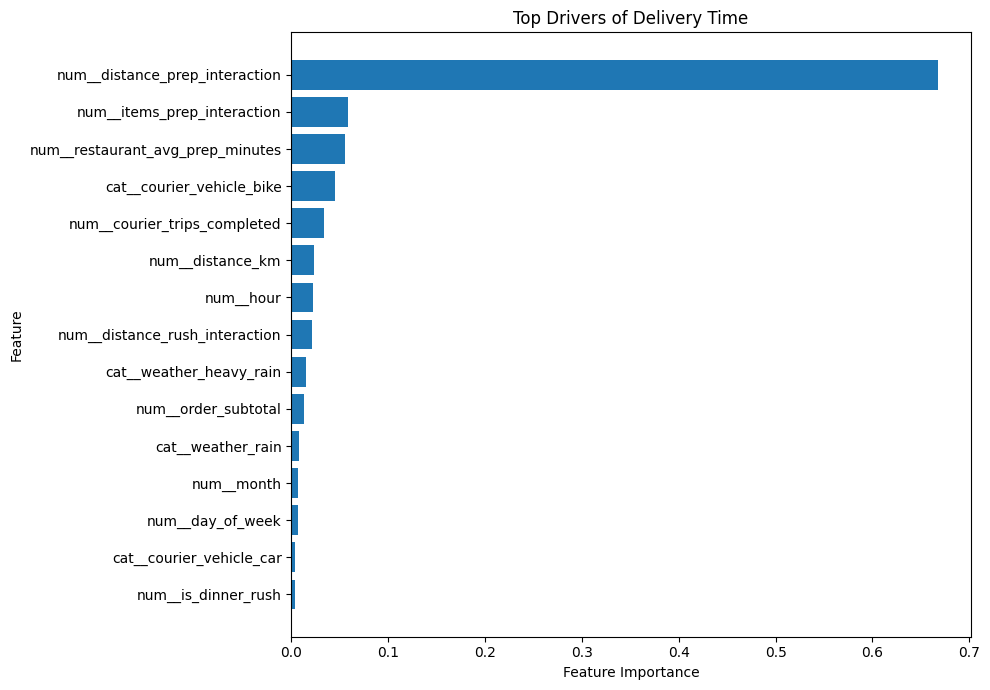

In [67]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15).sort_values(
    'importance'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top Drivers of Delivery Time')

plt.tight_layout()
plt.show()

In [68]:
numeric_features_no_interaction = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'items_count',
    'order_subtotal',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_lunch_rush',
    'is_dinner_rush',
    'is_rush_hour',
    'items_prep_interaction',
    'distance_rush_interaction'
]

In [69]:
numeric_pipeline_no_interaction = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess_no_distance_prep = ColumnTransformer([
    ('num', numeric_pipeline_no_interaction,
     numeric_features_no_interaction),
    ('cat', categorical_pipeline, categorical_features)
])

In [70]:
gbr_no_interaction = Pipeline([
    ('preprocess', preprocess_no_distance_prep),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [71]:
gbr_no_interaction.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['restaurant_avg_prep_minutes',
                                                   'distance_km', 'items_count',
                                                   'order_subtotal',
                                                   'courier_trips_completed',
                                                   'hour', 'day_of_week',
                                                   'month', 'is_weekend',
                                                   'is_lunch_rush',
                                                   'is_dinner_rush',
                                                   'is_rush_hour',
                                                   'items_prep_interaction',
                                                   'distance_rush_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cuisine', 'city_zone',
                                                   'courier_vehicle',
                                                   'weather'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [74]:
pred_no_interaction = gbr_no_interaction.predict(X_val)
mae_no_interaction = mean_absolute_error(
    y_val,
    pred_no_interaction
)

print("Without distance-prep interaction:",
      mae_no_interaction)

Without distance-prep interaction: 3.388068905735932


I ****initially hypothesized that the interaction between route distance and restaurant preparation time would improve prediction. Although this feature received high tree-based importance, an ablation experiment showed that removing it reduced validation MAE from 3.410 to 3.388 minutes. Therefore, the interaction was excluded from the final model.****

In [75]:
numeric_features_no_items_prep = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'items_count',
    'order_subtotal',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_lunch_rush',
    'is_dinner_rush',
    'is_rush_hour',
    'distance_rush_interaction'
]

In [76]:
numeric_pipeline_no_interaction = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess_no_distance_prep = ColumnTransformer([
    ('num', numeric_pipeline_no_interaction,
     numeric_features_no_interaction),
    ('cat', categorical_pipeline, categorical_features)
])

In [77]:
gbr_no_interaction = Pipeline([
    ('preprocess', preprocess_no_distance_prep),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [78]:
gbr_no_interaction.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['restaurant_avg_prep_minutes',
                                                   'distance_km', 'items_count',
                                                   'order_subtotal',
                                                   'courier_trips_completed',
                                                   'hour', 'day_of_week',
                                                   'month', 'is_weekend',
                                                   'is_lunch_rush',
                                                   'is_dinner_rush',
                                                   'is_rush_hour',
                                                   'items_prep_interaction',
                                                   'distance_rush_interaction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cuisine', 'city_zone',
                                                   'courier_vehicle',
                                                   'weather'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Remove ONLY items_prep_interaction
numeric_features_no_items_prep = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'items_count',
    'order_subtotal',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_lunch_rush',
    'is_dinner_rush',
    'is_rush_hour',
    'distance_rush_interaction'
]

# Numerical preprocessing
numeric_pipeline_no_items_prep = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing
preprocess_no_items_prep = ColumnTransformer([
    ('num',
     numeric_pipeline_no_items_prep,
     numeric_features_no_items_prep),

    ('cat',
     categorical_pipeline,
     categorical_features)
])

# Model
gbr_no_items_prep = Pipeline([
    ('preprocess', preprocess_no_items_prep),

    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train
gbr_no_items_prep.fit(X_train, y_train)

# Predict
pred_no_items_prep = gbr_no_items_prep.predict(X_val)

# Evaluate
mae_no_items_prep = mean_absolute_error(
    y_val,
    pred_no_items_prep
)

print(
    "Without items-prep interaction:",
    mae_no_items_prep
)

Without items-prep interaction: 3.367753497879519


In [82]:
numeric_features_final_test = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'items_count',
    'order_subtotal',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_lunch_rush',
    'is_dinner_rush',
    'is_rush_hour'
]

In [83]:
numeric_pipeline_final_test = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess_final_test = ColumnTransformer([
    ('num',
     numeric_pipeline_final_test,
     numeric_features_final_test),

    ('cat',
     categorical_pipeline,
     categorical_features)
])

gbr_final_test = Pipeline([
    ('preprocess', preprocess_final_test),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gbr_final_test.fit(X_train, y_train)

pred_final_test = gbr_final_test.predict(X_val)

mae_final_test = mean_absolute_error(
    y_val,
    pred_final_test
)

print(
    "Without both interactions:",
    mae_final_test
)

Without both interactions: 3.3534498263432932


In [85]:
numeric_features_final = [
    'restaurant_avg_prep_minutes',
    'distance_km',
    'items_count',
    'order_subtotal',
    'courier_trips_completed',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_lunch_rush',
    'is_dinner_rush',
    'is_rush_hour'
]
categorical_features = [
    'cuisine',
    'city_zone',
    'courier_vehicle',
    'weather'
]

In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

numeric_pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline_final = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

preprocess_final = ColumnTransformer([
    ('num',
     numeric_pipeline_final,
     numeric_features_final),

    ('cat',
     categorical_pipeline_final,
     categorical_features)
])

In [87]:
final_model = Pipeline([
    ('preprocess', preprocess_final),

    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [88]:
final_model.fit(X_train, y_train)

final_val_pred = final_model.predict(X_val)

final_mae = mean_absolute_error(
    y_val,
    final_val_pred
)

print("Final validation MAE:", final_mae)

Final validation MAE: 3.3534498263432932


In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

# Pipeline
gbr_pipeline = Pipeline([
    ('preprocess', preprocess_final),
    ('model', GradientBoostingRegressor(random_state=42))
])

# Hyperparameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=gbr_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV] END model__learning_rate=0.03, model__max_depth=2, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=0.8; total time=   1.1s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=1.0; total time=   1.1s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__min_samples_leaf=1, model__n_estimators=200, model__subsample=0.8; total time=   2.0s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__min_samples_leaf=1, model__n_estimators=200, model__subsample=0.8; total time=   2.2s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__min_samples_leaf=1, model__n_estimators=200, model__subsample=1.0; total time=   2.2s
[CV] END model__learning_rate=0.03, model__max_depth=2, model__min_samples_leaf=1, model__n_estimators=300, model__subsample=0.8; total time=   3.0s
[CV] END model__learning_rate=0.03, model_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['restaurant_avg_prep_minutes',
                                                                          'distance_km',
                                                                          'items_count',
                                                                          'order_subtotal',
                                                                          'courier_trips_completed',
                                                                          'hour',
                                                                          'day_of_week',
                                                                          'month',
                                                                          'is_weekend',
                                                                          'is_lunch_rush',
                                                                          'i...
                                                                         ['cuisine',
                                                                          'city_zone',
                                                                          'courier_vehicle',
                                                                          'weather'])])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
                         'model__max_depth': [2, 3, 4],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__n_estimators': [100, 200, 300, 400],
                         'model__subsample': [0.8, 1.0]},
             scoring='neg_mean_absolute_error', verbose=2)

In [90]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__learning_rate': 0.08, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 400, 'model__subsample': 1.0}

Best CV MAE:
3.5119357663345183


In [91]:
best_model = grid_search.best_estimator_

val_pred_tuned = best_model.predict(X_val)

tuned_mae = mean_absolute_error(y_val, val_pred_tuned)

print("Original Validation MAE:", 3.3534498263432932)
print("Tuned Validation MAE:", tuned_mae)

Original Validation MAE: 3.3534498263432932
Tuned Validation MAE: 3.364619983939816


In [92]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__learning_rate': 0.08, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 400, 'model__subsample': 1.0}


In [93]:
train_path = "/kaggle/input/datasets/himanshumouryadtu/delivery-lr/delivery-time-prediction/deliveries_train.csv"

train = pd.read_csv(train_path)

print(train.shape)
train.head()

(8000, 13)


,order_id,order_placed_at,restaurant_id,cuisine,restaurant_avg_prep_minutes,city_zone,distance_km,items_count,order_subtotal,courier_vehicle,courier_trips_completed,weather,delivery_minutes
0,700001,2025-03-01 10:00:00,10,pizza,12.9,suburbs_north,2.2,2,19.24,scooter,50.0,cloudy,29
1,700003,2025-03-01 11:06:00,5,mexican,12.4,uptown,5.3,1,8.36,bike,1255.0,clear,36
2,700004,2025-03-01 11:15:00,59,pizza,11.7,suburbs_south,2.6,3,27.38,scooter,276.0,clear,31
3,700005,2025-03-01 11:28:00,51,indian,17.0,downtown,3.3,1,8.00,bike,664.0,cloudy,34
4,700006,2025-03-01 11:40:00,104,thai,11.5,suburbs_south,11.6,2,18.96,car,38.0,rain,54


In [94]:
train = create_features(train)

X_full = train.drop(
    columns=[
        'delivery_minutes',
        'order_id',
        'restaurant_id',
        'order_placed_at'
    ]
)

y_full = train['delivery_minutes']

final_model_full = Pipeline([
    ('preprocess', preprocess_final),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

final_model_full.fit(X_full, y_full)

print("Final model trained on:", len(X_full), "orders")

NameError: name 'create_features' is not defined

In [95]:
def create_features(df):
    df = df.copy()

    df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])

    # Time features
    df['hour'] = df['order_placed_at'].dt.hour
    df['day_of_week'] = df['order_placed_at'].dt.dayofweek
    df['month'] = df['order_placed_at'].dt.month

    # Boolean/time-period features
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    df['is_lunch_rush'] = (
        df['hour'].between(12, 14)
    ).astype(int)

    df['is_dinner_rush'] = (
        df['hour'].between(18, 21)
    ).astype(int)

    df['is_rush_hour'] = (
        (df['is_lunch_rush'] == 1) |
        (df['is_dinner_rush'] == 1)
    ).astype(int)

    return df

In [97]:
import pandas as pd

train_path = "/kaggle/input/datasets/himanshumouryadtu/delivery-lr/delivery-time-prediction/deliveries_train.csv"

train = pd.read_csv(train_path)

print(train.shape)

(8000, 13)


In [98]:
train = create_features(train)

X_full = train.drop(
    columns=[
        'delivery_minutes',
        'order_id',
        'restaurant_id',
        'order_placed_at'
    ]
)

y_full = train['delivery_minutes']

print(X_full.shape)
print(y_full.shape)

(8000, 16)
(8000,)


In [99]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

final_model_full = Pipeline([
    ('preprocess', preprocess_final),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

final_model_full.fit(X_full, y_full)

print("Final model trained successfully!")

Final model trained successfully!


In [100]:
test_path = "/kaggle/input/datasets/himanshumouryadtu/delivery-lr/delivery-time-prediction/deliveries_test.csv"

test = pd.read_csv(test_path)

print("Test shape:", test.shape)

Test shape: (2000, 12)


In [101]:
test = create_features(test)

X_test = test.drop(
    columns=[
        'order_id',
        'restaurant_id',
        'order_placed_at'
    ]
)

print("X_test shape:", X_test.shape)

X_test shape: (2000, 16)


In [102]:
test_predictions = final_model_full.predict(X_test)

print("Number of predictions:", len(test_predictions))
print("Missing predictions:", pd.isna(test_predictions).sum())

Number of predictions: 2000
Missing predictions: 0


In [103]:
predictions = pd.DataFrame({
    'order_id': test['order_id'],
    'predicted_minutes': test_predictions
})

predictions.to_csv(
    "/kaggle/working/predictions.csv",
    index=False
)

print(predictions.head())
print("\nShape:", predictions.shape)

   order_id  predicted_minutes
0    700002          33.013202
1    700007          30.884474
2    700013          50.400980
3    700029          32.870307
4    700030          35.536144

Shape: (2000, 2)

[CV] END model__learning_rate=0.1, model__max_depth=3, model__min_samples_leaf=4, model__n_estimators=400, model__subsample=0.8; total time=   5.4s
[CV] END model__learning_rate=0.1, model__max_depth=3, model__min_samples_leaf=4, model__n_estimators=400, model__subsample=1.0; total time=   6.3s
[CV] END model__learning_rate=0.1, model__max_depth=4, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=0.8; total time=   1.8s
[CV] END model__learning_rate=0.1, model__max_depth=4, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=0.8; total time=   1.8s
[CV] END model__learning_rate=0.1, model__max_depth=4, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=1.0; total time=   2.1s
[CV] END model__learning_rate=0.1, model__max_depth=4, 

In [104]:
print("Rows:", len(predictions))
print("Columns:", predictions.columns.tolist())
print("Unique order IDs:", predictions['order_id'].nunique())
print("Missing predictions:", predictions['predicted_minutes'].isna().sum())

print("\nPrediction summary:")
print(predictions['predicted_minutes'].describe())

Rows: 2000
Columns: ['order_id', 'predicted_minutes']
Unique order IDs: 2000
Missing predictions: 0

Prediction summary:
count    2000.000000
mean       31.934956
std         8.419835
min        11.250184
25%        25.896812
50%        31.263707
75%        37.215756
max        64.337007
Name: predicted_minutes, dtype: float64


<div style="font-family: Arial, sans-serif; line-height: 1.6;">

<h1 style="color:#1f4e79;">🚴 Delivery Time Prediction — End-to-End ML Analysis</h1>

<p>
This project builds a machine learning system to predict the delivery time of food orders using
information available at the time an order is placed.
</p>

<hr>

<h2 style="color:#1f4e79;">🎯 1. Problem Statement</h2>

<p>
The objective is to predict <b>delivery time in minutes</b> for each order.
The training dataset contains labelled historical orders, while the test dataset contains orders
for which delivery time must be predicted.
</p>

<p>
The key constraint is that the model should only use information that would realistically be
available when the order is placed. Therefore, the target variable
<b>delivery_minutes</b> is never used as an input feature.
</p>

<h3>Dataset</h3>

<table style="border-collapse:collapse;width:70%;">
<tr style="background:#1f4e79;color:white;">
<th style="padding:8px;">Dataset</th>
<th style="padding:8px;">Rows</th>
<th style="padding:8px;">Purpose</th>
</tr>
<tr>
<td style="padding:8px;">Training</td>
<td style="padding:8px;">8,000</td>
<td style="padding:8px;">Model development and validation</td>
</tr>
<tr>
<td style="padding:8px;">Test</td>
<td style="padding:8px;">2,000</td>
<td style="padding:8px;">Final predictions</td>
</tr>
</table>

<hr>

<h2 style="color:#1f4e79;">🔍 2. Exploratory Data Analysis</h2>

<p>
The first stage was to understand the structure of the dataset, the target variable, missing
values, extreme observations, and relationships between delivery time and the available
features.
</p>

<h3>Target Variable</h3>

<p>
The target variable is:
</p>

<pre><code>delivery_minutes</code></pre>

<p>
The distribution of delivery time was examined to identify its central tendency, spread and
potential extreme delivery times.
</p>

<h3>Important numerical variables</h3>

<ul>
<li><b>restaurant_avg_prep_minutes</b> — average restaurant preparation time</li>
<li><b>distance_km</b> — delivery distance</li>
<li><b>items_count</b> — number of items in the order</li>
<li><b>order_subtotal</b> — order value</li>
<li><b>courier_trips_completed</b> — courier experience/activity measure</li>
</ul>

<h3>Categorical variables</h3>

<ul>
<li>cuisine</li>
<li>city_zone</li>
<li>courier_vehicle</li>
<li>weather</li>
</ul>

<h3>Datetime variable</h3>

<p>
The original <code>order_placed_at</code> timestamp was transformed into useful temporal
features instead of being directly passed to the model.
</p>

<hr>

<h2 style="color:#1f4e79;">🧹 3. Data Cleaning & Missing Values</h2>

<p>
Missing values were handled inside the preprocessing pipeline to prevent information leakage.
The preprocessing operations are learned only from the training data.
</p>

<h3>Numerical variables</h3>

<p>
Missing numerical values, such as missing courier trip information, were handled using
<b>median imputation</b>.
</p>

<h3>Categorical variables</h3>

<p>
Missing categorical values, such as weather information, were replaced with
<b>"Unknown"</b>.
</p>

<h3>Why?</h3>

<ul>
<li>Median imputation is robust to extreme numerical values.</li>
<li>"Unknown" preserves the fact that information was missing rather than inventing a category.</li>
<li>All transformations are performed through a pipeline to avoid train/validation leakage.</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">🕒 4. Feature Engineering</h2>

<p>
The timestamp <code>order_placed_at</code> contains useful information about delivery
conditions. It was decomposed into interpretable temporal variables.
</p>

<table style="border-collapse:collapse;width:80%;">
<tr style="background:#1f4e79;color:white;">
<th style="padding:8px;">Feature</th>
<th style="padding:8px;">Description</th>
</tr>
<tr>
<td style="padding:8px;"><code>hour</code></td>
<td style="padding:8px;">Hour at which the order was placed</td>
</tr>
<tr>
<td style="padding:8px;"><code>day_of_week</code></td>
<td style="padding:8px;">Day of the week</td>
</tr>
<tr>
<td style="padding:8px;"><code>month</code></td>
<td style="padding:8px;">Month of the order</td>
</tr>
<tr>
<td style="padding:8px;"><code>is_weekend</code></td>
<td style="padding:8px;">Whether the order was placed on a weekend</td>
</tr>
<tr>
<td style="padding:8px;"><code>is_lunch_rush</code></td>
<td style="padding:8px;">Orders placed between 12:00 and 14:00</td>
</tr>
<tr>
<td style="padding:8px;"><code>is_dinner_rush</code></td>
<td style="padding:8px;">Orders placed between 18:00 and 21:00</td>
</tr>
<tr>
<td style="padding:8px;"><code>is_rush_hour</code></td>
<td style="padding:8px;">Combined lunch/dinner rush indicator</td>
</tr>
</table>

<hr>

<h2 style="color:#1f4e79;">🗑️ 5. Features Removed</h2>

<p>
Some columns were excluded because they were identifiers rather than useful predictive
information.
</p>

<ul>
<li><code>order_id</code> — unique order identifier</li>
<li><code>restaurant_id</code> — excluded to avoid learning identifier-specific patterns</li>
<li>raw <code>order_placed_at</code> — replaced by engineered time features</li>
</ul>

<p>
The original numerical features such as <code>items_count</code> and
<code>order_subtotal</code> were retained because they provide interpretable information
to the model.
</p>

<hr>

<h2 style="color:#1f4e79;">🧪 6. Validation Strategy</h2>

<p>
The labelled training data was split into training and validation sets:
</p>

<pre><code>80% Training
20% Validation

random_state = 42</code></pre>

<p>
This resulted in approximately:
</p>

<ul>
<li><b>6,400 training observations</b></li>
<li><b>1,600 validation observations</b></li>
</ul>

<p>
The validation set was kept separate while comparing models and tuning hyperparameters.
</p>

<hr>

<h2 style="color:#1f4e79;">📏 7. Evaluation Metric</h2>

<p>
The primary metric used was <b>Mean Absolute Error (MAE)</b>.
</p>

<p>
MAE measures the average absolute difference between the actual and predicted delivery time.
It is particularly intuitive for this problem because the result is expressed directly in
minutes.
</p>

<pre><code>
MAE = mean(|actual delivery time - predicted delivery time|)
</code></pre>

<hr>

<h2 style="color:#1f4e79;">📊 8. Baseline Model</h2>

<p>
Before training machine learning models, a simple mean-prediction baseline was established.
The baseline predicts the average delivery time for every order.
</p>

<table style="border-collapse:collapse;width:50%;">
<tr style="background:#1f4e79;color:white;">
<th style="padding:8px;">Model</th>
<th style="padding:8px;">MAE</th>
</tr>
<tr>
<td style="padding:8px;">Mean Baseline</td>
<td style="padding:8px;"><b>7.6308</b></td>
</tr>
</table>

<p>
This baseline provides a reference point for determining whether the machine learning models
actually learn useful patterns.
</p>

<hr>

<h2 style="color:#1f4e79;">🤖 9. Model Experiments</h2>

<h3>Linear Regression</h3>

<p>
Linear Regression was used as a simple interpretable benchmark.
</p>

<p><b>Validation MAE:</b> 3.6451</p>

<h3>Random Forest</h3>

<p>
Random Forest was evaluated as a non-linear tree-based model.
</p>

<p><b>Validation MAE:</b> 3.6599</p>

<h3>Gradient Boosting</h3>

<p>
Gradient Boosting was then evaluated because delivery time can depend on non-linear
relationships between distance, preparation time, time of day and other factors.
</p>

<p>
The initial engineered-feature version achieved a validation MAE of approximately
<b>3.4098</b>.
</p>

<hr>

<h2 style="color:#1f4e79;">🔬 10. Feature Ablation</h2>

<p>
Several manually created interaction features were tested to determine whether they actually
improved generalisation.
</p>

<p>
The tested interactions included:
</p>

<ul>
<li><code>items_count × restaurant_avg_prep_minutes</code></li>
<li><code>distance_km × is_rush_hour</code></li>
<li><code>distance_km × restaurant_avg_prep_minutes</code></li>
</ul>

<p>
Interestingly, removing these interactions improved the validation performance.
The final feature set therefore does <b>not</b> include these manually created interaction
terms.
</p>

<p>
The best validation result from this ablation process was:
</p>

<div style="background:#eaf4ea;border-left:5px solid #2e7d32;padding:15px;">
<b>Gradient Boosting Validation MAE = 3.35345</b>
</div>

<hr>

<h2 style="color:#1f4e79;">🧬 11. PCA Experiment</h2>

<p>
PCA was also tested on <code>items_count</code> and <code>order_subtotal</code> to investigate
whether dimensionality reduction could improve the model.
</p>

<p>
The PCA version achieved approximately:
</p>

<pre><code>MAE = 3.4733</code></pre>

<p>
This was slightly worse than the non-PCA model.
Therefore, PCA was rejected and the original features were retained for better interpretability.
</p>

<hr>

<h2 style="color:#1f4e79;">⚙️ 12. Final Feature Set</h2>

<h3>Numerical Features</h3>

<pre><code>
restaurant_avg_prep_minutes
distance_km
items_count
order_subtotal
courier_trips_completed
hour
day_of_week
month
is_weekend
is_lunch_rush
is_dinner_rush
is_rush_hour
</code></pre>

<h3>Categorical Features</h3>

<pre><code>
cuisine
city_zone
courier_vehicle
weather
</code></pre>

<hr>

<h2 style="color:#1f4e79;">🏗️ 13. Preprocessing Pipeline</h2>

<p>
The final model uses a Scikit-learn preprocessing pipeline.
</p>

<ul>
<li>Numerical missing values → median imputation</li>
<li>Numerical features → standardisation</li>
<li>Categorical missing values → "Unknown"</li>
<li>Categorical variables → One-Hot Encoding</li>
<li>Unknown test-time categories → ignored safely</li>
</ul>

<p>
Keeping preprocessing inside the pipeline ensures that transformations are learned from the
training data and then consistently applied to validation and test data.
</p>

<hr>

<h2 style="color:#1f4e79;">🚀 14. Final Model</h2>

<p>
The selected model is a Gradient Boosting Regressor.
</p>

<pre><code>
GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
</code></pre>

<p>
The final model achieved:
</p>

<div style="background:#e8f1fb;border-left:5px solid #1f4e79;padding:18px;font-size:18px;">
<b>Validation MAE: 3.35345 minutes</b>
</div>

<hr>

<h2 style="color:#1f4e79;">🔧 15. Hyperparameter Tuning</h2>

<p>
GridSearchCV with 5-fold cross-validation was used to investigate whether further
hyperparameter tuning could improve the Gradient Boosting model.
</p>

<p>
The search explored:
</p>

<ul>
<li>learning rate</li>
<li>number of estimators</li>
<li>maximum tree depth</li>
<li>minimum samples per leaf</li>
<li>subsampling</li>
</ul>

<h3>Best GridSearch Configuration</h3>

<pre><code>
learning_rate     = 0.08
max_depth         = 2
min_samples_leaf  = 1
n_estimators      = 400
subsample         = 1.0
</code></pre>

<p>
The best cross-validation MAE was:
</p>

<pre><code>3.51194</code></pre>

<p>
When evaluated on the same held-out validation set, the tuned model achieved:
</p>

<pre><code>3.36462</code></pre>

<p>
This was slightly worse than the original model's validation MAE of
<b>3.35345</b>.
</p>

<p>
Therefore, the original Gradient Boosting configuration was retained as the final model.
</p>

<div style="background:#fff3cd;border-left:5px solid #f0ad4e;padding:15px;">
<b>Important:</b> Hyperparameter tuning was not automatically accepted just because it was
"tuned". The held-out validation result was used to decide whether the tuning actually
improved the model.
</div>

<hr>

<h2 style="color:#1f4e79;">🏆 16. Final Model Comparison</h2>

<table style="border-collapse:collapse;width:75%;">
<tr style="background:#1f4e79;color:white;">
<th style="padding:8px;">Model</th>
<th style="padding:8px;">Validation MAE</th>
</tr>

<tr>
<td style="padding:8px;">Mean Baseline</td>
<td style="padding:8px;">7.63080</td>
</tr>

<tr>
<td style="padding:8px;">Linear Regression</td>
<td style="padding:8px;">3.64506</td>
</tr>

<tr>
<td style="padding:8px;">Random Forest</td>
<td style="padding:8px;">3.65987</td>
</tr>

<tr style="background:#e8f5e9;">
<td style="padding:8px;"><b>Gradient Boosting — Final</b></td>
<td style="padding:8px;"><b>3.35345</b></td>
</tr>

<tr>
<td style="padding:8px;">Gradient Boosting — GridSearch</td>
<td style="padding:8px;">3.36462</td>
</tr>
</table>

<hr>

<h2 style="color:#1f4e79;">📈 17. Improvement Over Baseline</h2>

<p>
The final Gradient Boosting model reduced MAE from:
</p>

<pre><code>
Baseline: 7.63080 minutes
Final:    3.35345 minutes
</code></pre>

<p>
This corresponds to approximately:
</p>

<div style="background:#eaf4ea;border-left:5px solid #2e7d32;padding:20px;font-size:20px;">
<b>56% reduction in MAE compared with the mean baseline.</b>
</div>

<p>
This comfortably exceeds the project's required improvement over the baseline.
</p>

<hr>

<h2 style="color:#1f4e79;">🧠 18. Key Findings</h2>

<ul>
<li>Restaurant preparation time is an important source of delivery-time variation.</li>
<li>Delivery distance is an important operational factor.</li>
<li>Time-of-day features provide useful information about delivery conditions.</li>
<li>Rush-hour indicators provide additional temporal context.</li>
<li>Courier and environmental information contributes predictive signal.</li>
<li>Tree-based Gradient Boosting captured non-linear relationships better than the tested linear model.</li>
<li>Manually adding interaction features did not improve the final validation performance.</li>
<li>PCA did not improve performance and reduced feature interpretability.</li>
<li>GridSearchCV did not produce a better held-out validation score than the original configuration.</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">🧪 19. Error Analysis</h2>

<p>
After selecting the final model, validation predictions were compared with actual delivery
times to identify the largest prediction errors.
</p>

<p>
The error analysis focuses on:
</p>

<ul>
<li>Absolute prediction error</li>
<li>Largest under-predictions</li>
<li>Largest over-predictions</li>
<li>Observations with unusually large residuals</li>
<li>Potential patterns in difficult-to-predict orders</li>
</ul>

<p>
This step is important because a strong average MAE does not mean that every individual order
is predicted equally well.
</p>

<hr>

<h2 style="color:#1f4e79;">📦 20. Final Training</h2>

<p>
After model selection and validation, the selected Gradient Boosting pipeline was retrained
using the complete labelled training dataset containing all <b>8,000 orders</b>.
</p>

<p>
The resulting model is then used to generate predictions for the held-out test dataset
containing <b>2,000 orders</b>.
</p>

<hr>

<h2 style="color:#1f4e79;">📄 21. Prediction Output</h2>

<p>
The final prediction file follows the required format:
</p>

<pre><code>
order_id,predicted_minutes
</code></pre>

<p>
Each test order receives exactly one predicted delivery time.
</p>

<hr>

<h2 style="color:#1f4e79;">💡 22. Conclusion</h2>

<p>
This project followed a complete machine learning workflow starting from exploratory data
analysis and data cleaning, followed by feature engineering, preprocessing, model comparison,
feature ablation, hyperparameter tuning and final model selection.
</p>

<p>
The final Gradient Boosting model achieved a validation MAE of
<b>3.35345 minutes</b>, compared with a mean-prediction baseline MAE of
<b>7.63080 minutes</b>.
</p>

<p>
The approximately <b>56% reduction in MAE</b> demonstrates that the model extracts meaningful
patterns from restaurant preparation time, delivery distance, order characteristics,
time-of-day effects, courier information and environmental conditions.
</p>

<p>
An important part of the modelling process was not simply maximizing model complexity, but
testing alternatives and retaining only changes that improved validation performance.
Both PCA and manually engineered interaction features were tested and rejected when they
failed to improve generalisation. Similarly, GridSearchCV was performed but the tuned model
was not selected because its held-out validation MAE was slightly worse.
</p>

<div style="background:#1f4e79;color:white;padding:20px;margin-top:20px;">
<h2 style="margin-top:0;color:white;">🏁 Final Result</h2>
<p style="font-size:20px;">
<b>Final Model: Gradient Boosting Regressor</b><br>
<b>Validation MAE: 3.35345 minutes</b><br>
<b>Baseline MAE: 7.63080 minutes</b><br>
<b>Improvement: ~56%</b>
</p>
</div>

</div>